#Zomato Dataset

##Importing Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text cleaning
import re
import string

# Text vecotrizing and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Saving files
import joblib

##Loading Dataset

In [2]:
zomato = pd.read_csv('/content/zomato.csv', encoding='latin-1')
display(zomato.head())

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


##Filtering only the UAE rows

In [3]:
zomato = zomato[zomato["Country Code"] == 214]

### Data inspection

In [4]:
zomato.shape

(60, 21)

In [5]:
zomato.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [6]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 564 to 623
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         60 non-null     int64  
 1   Restaurant Name       60 non-null     object 
 2   Country Code          60 non-null     int64  
 3   City                  60 non-null     object 
 4   Address               60 non-null     object 
 5   Locality              60 non-null     object 
 6   Locality Verbose      60 non-null     object 
 7   Longitude             60 non-null     float64
 8   Latitude              60 non-null     float64
 9   Cuisines              60 non-null     object 
 10  Average Cost for two  60 non-null     int64  
 11  Currency              60 non-null     object 
 12  Has Table booking     60 non-null     object 
 13  Has Online delivery   60 non-null     object 
 14  Is delivering now     60 non-null     object 
 15  Switch to order menu  60 no

In [7]:
zomato.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [8]:
zomato['Restaurant ID'].duplicated().sum()

np.int64(0)

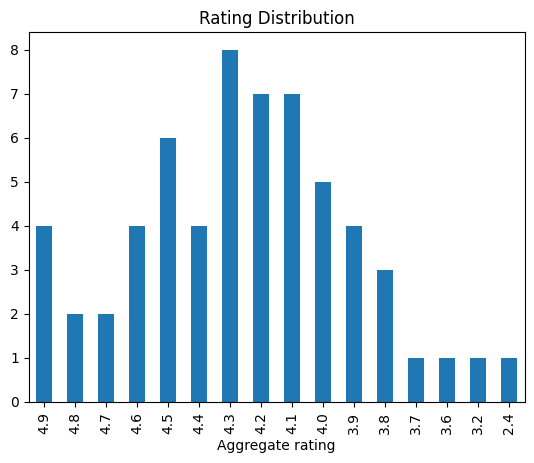

In [9]:
zomato["Aggregate rating"].value_counts().sort_index(ascending = False).plot(kind = "bar", title = "Rating Distribution")
plt.show()

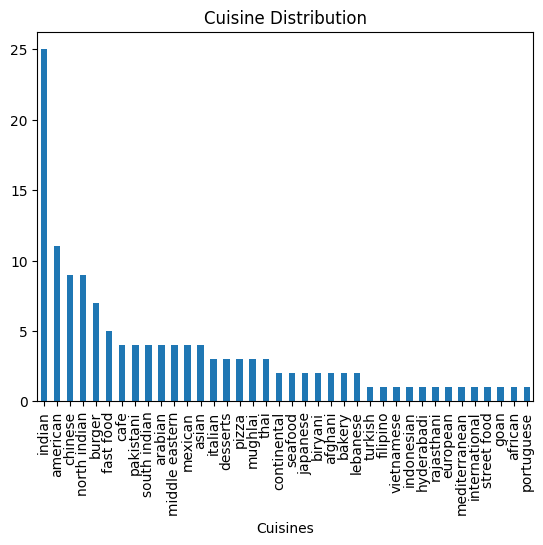

In [10]:
zomato["Cuisines"] = zomato["Cuisines"].fillna("").str.lower()
zomato["Cuisines"].str.split(",").explode().str.strip().value_counts().plot(
    kind="bar",
    title="Cuisine Distribution"
)

plt.show()

In [11]:
# Changing column names
zomato = zomato.rename(columns={'Restaurant ID': 'restaurant_id', 'Restaurant Name': 'restaurant_name', 'Country Code': 'country_code', 'City': 'city',
                                'Address': 'address', 'Locality': 'locality', 'Locality Verbose': 'locality_verbose', 'Longitude': 'longitude', 'Latitude': 'latitude', 'Cuisines': 'cuisines', 'Currency ': 'currency',
                                'Has Table booking': 'has_table_booking', 'Average Cost for two': 'average_cost_for_two','Has Online delivery': 'has_online_delivery', 'Is delivering now': 'is_delivering_now', 'Switch to order menu': 'switch_to_order_menu',
                                'Price range': 'price_range', 'Aggregate rating': 'rating', 'Rating color': 'rating_color', 'Rating text': 'rating_text', 'Votes': 'votes','Currency': 'currency'})
zomato.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'rating', 'rating_color', 'rating_text', 'votes'],
      dtype='object')

## Feature Engineering

In [12]:
zomato['price_range'].value_counts()

,count
price_range,
3,29
4,22
2,9


In [13]:
# Changing price to high mediem low
zomato['price_level'] = zomato['price_range'].map({2: 'low', 3: 'medium', 4: 'high'})
zomato['price_level'].value_counts()

,count
price_level,
medium,29
high,22
low,9


In [14]:
zomato["rating_score"] = zomato["rating"] / 5

In [15]:
zomato["popularity_score"] = zomato["votes"] / zomato["votes"].max()
# vote is used as popularity

In [16]:
display(
    zomato[['popularity_score', 'rating_score']].head()
    )

,popularity_score,rating_score
564,0.082470,0.92
565,0.149801,0.92
566,0.187649,0.88
567,0.089243,0.86
568,0.090837,0.84


## Feature Selection

In [17]:
zomato.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'rating', 'rating_color', 'rating_text', 'votes',
       'price_level', 'rating_score', 'popularity_score'],
      dtype='object')

In [18]:
zomato_useful_features = ['restaurant_name', 'city', 'cuisines', 'price_level', 'rating_score', 'popularity_score']

In [19]:
zomato_content = ['restaurant_name', 'city', 'cuisines']

**Useful Features:**

The useful features are the restaurant name, city, cuisines.

Name, City, and Cusine will be used for the content to compare similarity.

Price level, City, and Cusinines will be used for filtering.

 The ratings and popularity will be used for ranking with a formula. 75% similariy, 15% rating, and 10% popularity.

**Purpose:**

The purpose is to recommend restaurants that best match the users prefernces using cintent based filtering. The system filters the restaurants based on the users city, preferred cuisines, and budget, then ranks the candidates using similarity, ratings, and popularity.

##Creating Restaurant Content

In [20]:
zomato['content'] = (
    zomato['restaurant_name'].fillna('') + ' ' +
    zomato['city'].fillna('') + ' ' +
    zomato['cuisines'].fillna('')
).str.lower()

In [21]:
display(
    zomato[['restaurant_name', 'content']].head()
)

,restaurant_name,content
564,Denny's,denny's abu dhabi american
565,Famous Dave's Barbecue,famous dave's barbecue abu dhabi american
566,Pizza Di Rocco,"pizza di rocco abu dhabi italian, pizza"
567,Sofra Istanbul,"sofra istanbul abu dhabi turkish, arabian, mid..."
568,Salt,"salt abu dhabi fast food, burger"


##Creating User Profile

In [22]:
user_profile = {
    'user_id': '1234',
    'city': ['Abu Dhabi'],
    'cuisines': ['Pizza', 'Chinese'],
    'budget': 'medium',
    'top_n': 5
}

user_query = " ".join([
    " ".join(user_profile["city"]),
    " ".join(user_profile["cuisines"])
])

user_query

'Abu Dhabi Pizza Chinese'

##Text Vectorizing

In [23]:
vectorizer = TfidfVectorizer(stop_words = 'english')
item_matrix = vectorizer.fit_transform(zomato['content'].fillna(""))
user_matrix = vectorizer.transform([user_query])

##Calculating User-to-Item Similary Scores

In [24]:
similarity_scores = cosine_similarity(user_matrix, item_matrix).flatten()

zomato["similarity_score"] = similarity_scores

display(
    zomato[["restaurant_name", "price_level", "city", "cuisines", "similarity_score"]]
    .sort_values(by="similarity_score", ascending=False).head(10))


,restaurant_name,price_level,city,cuisines,similarity_score
566,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592
613,Pizza Hut,medium,Sharjah,"fast food, pizza",0.503271
582,P.F. Chang's,high,Abu Dhabi,chinese,0.497760
570,Olive Garden,high,Abu Dhabi,"italian, pizza",0.469164
579,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241
571,Cho Gao - Crowne Plaza Abu Dhabi,high,Abu Dhabi,"thai, japanese, chinese, indonesian, vietnamese",0.329816
617,Peking Chinese Restaurant,high,Sharjah,"chinese, thai",0.319932
581,Tamba,high,Abu Dhabi,indian,0.277081
564,Denny's,high,Abu Dhabi,american,0.262418
578,Indian By Nature,medium,Abu Dhabi,indian,0.241603


Our user wants medium price level and they are in Abu Dhabi, so offcourse this needs filtering

##Applying Filters

In [25]:
candidates_df = zomato[
    zomato["city"].str.lower().isin(
        [city.lower() for city in user_profile["city"]]
    )
].copy()

selected_cuisines = [cuisine.lower() for cuisine in user_profile["cuisines"]]

candidates_df = candidates_df[
    candidates_df["cuisines"].apply(
        lambda x: any(cuisine in x for cuisine in selected_cuisines)
    )
].copy()

budget = user_profile["budget"].lower()

if budget == "low":
  candidates_df = candidates_df[
      candidates_df["price_level"] == "low"
      ].copy()
elif budget == "medium":
  candidates_df = candidates_df[
      candidates_df["price_level"].isin(["low", "medium"])
      ].copy()
elif budget == "high":
  candidates_df = candidates_df[
      candidates_df["price_level"].isin(["low", "medium", "high"])
      ].copy()



candidates_df['fallback_stage'] = 'strict_match'


In [26]:
display(
    candidates_df[["restaurant_name", "price_level", "city", "cuisines", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,restaurant_name,price_level,city,cuisines,similarity_score,fallback_stage
566,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592,strict_match
579,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241,strict_match


We are on the right track

## Fallback Stage

In [27]:
required_count = user_profile["top_n"]


def add_new_candidates(current_df, new_df, stage_name, required_count):

    new_df = new_df[
        ~new_df["restaurant_name"].isin(
            current_df["restaurant_name"]
        )
    ].copy()

    needed = required_count - len(current_df)

    if needed > 0:

        new_df = (
            new_df
            .sort_values(
                by="similarity_score",
                ascending=False
            )
            .head(needed)
        )

        new_df["fallback_stage"] = stage_name

        current_df = pd.concat(
            [current_df, new_df],
            ignore_index=True
        )

    return current_df

In [28]:
# Relax budget
if len(candidates_df) < required_count:

    relaxed_budget_df = zomato[
        zomato["city"].str.lower().isin(
            [city.lower() for city in user_profile["city"]]
        )
    ].copy()

    relaxed_budget_df = relaxed_budget_df[
        relaxed_budget_df["cuisines"].apply(
            lambda x: any(cuisine in x for cuisine in selected_cuisines)
        )
    ].copy()


    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_budget_df,
        "relaxed_budget",
        required_count
    )

display(
    candidates_df[["restaurant_name", "price_level", "city", "cuisines", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,restaurant_name,price_level,city,cuisines,similarity_score,fallback_stage
0,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592,strict_match
2,P.F. Chang's,high,Abu Dhabi,chinese,0.497760,relaxed_budget
3,Olive Garden,high,Abu Dhabi,"italian, pizza",0.469164,relaxed_budget
1,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241,strict_match
4,Cho Gao - Crowne Plaza Abu Dhabi,high,Abu Dhabi,"thai, japanese, chinese, indonesian, vietnamese",0.329816,relaxed_budget


In [29]:
# Relax budget and cuisines
if len(candidates_df) < required_count:

    relaxed_budget_cuisine_df = zomato[
        zomato["city"].str.lower().isin(
            [city.lower() for city in user_profile["city"]]
        )
    ].copy()

    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_budget_cuisine_df,
        "relaxed_budget_cuisine",
        required_count
    )

display(
    candidates_df[["restaurant_name", "price_level", "city", "cuisines", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,restaurant_name,price_level,city,cuisines,similarity_score,fallback_stage
0,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592,strict_match
2,P.F. Chang's,high,Abu Dhabi,chinese,0.497760,relaxed_budget
3,Olive Garden,high,Abu Dhabi,"italian, pizza",0.469164,relaxed_budget
1,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241,strict_match
4,Cho Gao - Crowne Plaza Abu Dhabi,high,Abu Dhabi,"thai, japanese, chinese, indonesian, vietnamese",0.329816,relaxed_budget


In [30]:
# Expand city
if len(candidates_df) < required_count:

    relaxed_city_df = zomato.copy()

    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_city_df,
        "relaxed_city",
        required_count
    )

display(
    candidates_df[["restaurant_name", "price_level", "city", "cuisines", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)


,restaurant_name,price_level,city,cuisines,similarity_score,fallback_stage
0,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592,strict_match
2,P.F. Chang's,high,Abu Dhabi,chinese,0.497760,relaxed_budget
3,Olive Garden,high,Abu Dhabi,"italian, pizza",0.469164,relaxed_budget
1,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241,strict_match
4,Cho Gao - Crowne Plaza Abu Dhabi,high,Abu Dhabi,"thai, japanese, chinese, indonesian, vietnamese",0.329816,relaxed_budget


Fallback stage is completed successfully.

## Ranking with Quality Signals

In [31]:
candidates_df["final_score"] = (
    0.75 * candidates_df["similarity_score"] +
    0.15 * candidates_df["rating_score"] +
    0.1 * candidates_df["popularity_score"]
)

final_recommendations = candidates_df.sort_values(
    by="final_score",
    ascending=False
)

final_recommendations["rank"] = range(
    1,
    len(final_recommendations) + 1
)

display(
    final_recommendations[["restaurant_name", "price_level", "city", "cuisines", "similarity_score", "rating_score", "popularity_score", "final_score", "rank"]]
    .sort_values(by="final_score", ascending=False)
)

,restaurant_name,price_level,city,cuisines,similarity_score,rating_score,popularity_score,final_score,rank
0,Pizza Di Rocco,medium,Abu Dhabi,"italian, pizza",0.609592,0.88,0.187649,0.607959,1
2,P.F. Chang's,high,Abu Dhabi,chinese,0.497760,0.84,0.173307,0.516650,2
3,Olive Garden,high,Abu Dhabi,"italian, pizza",0.469164,0.82,0.168127,0.491685,3
1,Via Delhi,medium,Abu Dhabi,"indian, north indian, chinese",0.395241,0.80,0.209163,0.437347,4
4,Cho Gao - Crowne Plaza Abu Dhabi,high,Abu Dhabi,"thai, japanese, chinese, indonesian, vietnamese",0.329816,0.88,0.098008,0.389163,5


It chose the first two because of similarity mostly, then rating, then chose to rank the indian because of their similarity, rating, and popularity.

##Reason for Recommendation

In [32]:
def recommendation_reason(row, user_profile):

    reasons = []

    if row["fallback_stage"] == "strict_match":
        reasons.append(
            "matches your city, cuisine and budget preferences"
        )

    elif row["fallback_stage"] == "relaxed_budget":
        reasons.append(
            "matches your city and cuisine preferences"
        )
        reasons.append(
            "budget preference was relaxed"
        )

    elif row["fallback_stage"] == "relaxed_cuisine":
        reasons.append(
            "matches your city and budget preferences"
        )
        reasons.append(
            "cuisine preference was relaxed"
        )

    elif row["fallback_stage"] == "relaxed_budget_cuisine":
        reasons.append(
            "matches your city preference"
        )
        reasons.append(
            "budget and cuisine preferences were relaxed"
        )

    elif row["fallback_stage"] == "relaxed_city":
        reasons.append(
            "the search was expanded to other cities"
        )
        reasons.append(
            "all preferences were relaxed"
        )

    if row["rating_score"] >= 0.90:
        reasons.append(
            "has excellent ratings"
        )
    else:
        reasons.append(
            "has good ratings"
        )

    if row["popularity_score"] >= 0.70:
        reasons.append(
            "is popular with visitors"
        )
    else:
        reasons.append(
            "is worth trying"
        )

    return "; ".join(reasons) + "."


final_recommendations["recommendation_reason"] = (
    final_recommendations.apply(
        lambda row: recommendation_reason(
            row,
            user_profile
        ),
        axis=1
    )
)

display(
    final_recommendations[
        [
            "restaurant_name",
            "recommendation_reason"
        ]
    ]
)

,restaurant_name,recommendation_reason
0,Pizza Di Rocco,"matches your city, cuisine and budget preferen..."
2,P.F. Chang's,matches your city and cuisine preferences; bud...
3,Olive Garden,matches your city and cuisine preferences; bud...
1,Via Delhi,"matches your city, cuisine and budget preferen..."
4,Cho Gao - Crowne Plaza Abu Dhabi,matches your city and cuisine preferences; bud...


##Building the recommendation system (User to Item)

In [33]:
def recommend_restaurants(user_profile, zomato, vectorizer, item_matrix):
    required_count = user_profile['top_n']

    user_query = " ".join([
        " ".join(user_profile["city"]),
        " ".join(user_profile["cuisines"])
    ])

    # Calculating Similarity

    user_matrix = vectorizer.transform([user_query])

    similarity_scores = cosine_similarity(
        user_matrix,
        item_matrix
    ).flatten()

    zomato["similarity_score"] = similarity_scores

    budget = user_profile["budget"].lower()

    if budget == "low":
        allowed_prices = ["low"]

    elif budget == "medium":
        allowed_prices = ["low", "medium"]

    else:
        allowed_prices = ["low", "medium", "high"]

    # Strict match
    candidates_df = zomato[
        zomato["city"].str.lower().isin(
            [city.lower() for city in user_profile["city"]]
        )
    ].copy()

    selected_cuisines = [
        cuisine.lower()
        for cuisine in user_profile["cuisines"]
    ]

    candidates_df = candidates_df[
        candidates_df["cuisines"].apply(
            lambda x: any(cuisine in x for cuisine in selected_cuisines)
        )
    ]

    candidates_df = candidates_df[
        candidates_df["price_level"].isin(allowed_prices)
    ].copy()

    candidates_df["fallback_stage"] = "strict_match"

    # Relax budget
    if len(candidates_df) < required_count:

        relaxed_budget_df = zomato[
            zomato["city"].str.lower().isin(
                [city.lower() for city in user_profile["city"]]
            )
        ].copy()

        relaxed_budget_df = relaxed_budget_df[
            relaxed_budget_df["cuisines"].apply(
                lambda x: any(cuisine in x for cuisine in selected_cuisines)
            )
        ].copy()

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_budget_df,
            "relaxed_budget",
            required_count
        )

    # Relax cuisine
    if len(candidates_df) < required_count:

        relaxed_cuisine_df = zomato[
            zomato["city"].str.lower().isin(
                [city.lower() for city in user_profile["city"]]
            )
        ].copy()

        relaxed_cuisine_df = relaxed_cuisine_df[
            relaxed_cuisine_df["price_level"].isin(
                allowed_prices
            )
        ].copy()

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_cuisine_df,
            "relaxed_cuisine",
            required_count
        )

    # Relax budget and expand cuisines
    if len(candidates_df) < required_count:

        relaxed_budget_cuisine_df = zomato[
            zomato["city"].str.lower().isin(
                [city.lower() for city in user_profile["city"]]
            )
        ].copy()

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_budget_cuisine_df,
            "relaxed_budget_cuisine",
            required_count
        )

    # Expand city
    if len(candidates_df) < required_count:

        relaxed_city_df = zomato.copy()

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_city_df,
            "relaxed_city",
            required_count
        )

    # Qualy signs
    candidates_df["final_score"] = (
        0.75 * candidates_df["similarity_score"] +
        0.15 * candidates_df["rating_score"] +
        0.10 * candidates_df["popularity_score"]
    )

    candidates_df = candidates_df.sort_values(
        by="final_score",
        ascending=False
    ).head(required_count)

    candidates_df["rank"] = range(
        1,
        len(candidates_df) + 1
    )

    candidates_df["recommendation_reason"] = (
        candidates_df.apply(
            lambda row: recommendation_reason(
                row,
                user_profile
            ),
            axis=1
        )
    )

    candidates_df = candidates_df[
        [
            "restaurant_name",
            "city",
            "cuisines",
            "price_level",
            "rating_score",
            "popularity_score",
            "final_score",
            "rank",
            "fallback_stage",
            "recommendation_reason"
        ]
    ]

    return candidates_df

##Testing

In [34]:
new_user = {
    "city": ["Dubai"],
    "cuisines": ["Italian", "Mexican"],
    "budget": "medium",
    "top_n": 5
}

new_user2 = {
    "city": ["Sharjah"],
    "cuisines": ["Chinese", "Indian"],
    "budget": "low",
    "top_n": 7
}

new_user3 = {
    "city": ["Abu Dhabi"],
    "cuisines": ["American", "Italian"],
    "budget": "medium",
    "top_n": 6

}



In [35]:
recommend_restaurants(new_user, zomato, vectorizer, item_matrix)

,restaurant_name,city,cuisines,price_level,rating_score,popularity_score,final_score,rank,fallback_stage,recommendation_reason
1,Applebee's,Dubai,"american, mexican, burger",medium,0.74,0.199203,0.460688,1,strict_match,"matches your city, cuisine and budget preferen..."
0,The Farm,Dubai,"mediterranean, italian, thai, european",medium,0.78,0.369323,0.413244,2,strict_match,"matches your city, cuisine and budget preferen..."
3,Rasoi Ghar,Dubai,indian,low,0.86,0.510359,0.265118,3,relaxed_cuisine,matches your city and budget preferences; cuis...
4,SALT,Dubai,"fast food, burger",medium,0.86,0.538247,0.264479,4,relaxed_cuisine,matches your city and budget preferences; cuis...
2,Parker's,Dubai,"cafe, burger",medium,0.86,0.153785,0.232955,5,relaxed_cuisine,matches your city and budget preferences; cuis...


In [36]:
recommend_restaurants(new_user2, zomato, vectorizer, item_matrix)

,restaurant_name,city,cuisines,price_level,rating_score,popularity_score,final_score,rank,fallback_stage,recommendation_reason
0,Kamat,Sharjah,"indian, north indian, south indian, chinese",medium,0.78,0.113546,0.594254,1,relaxed_budget,matches your city and cuisine preferences; bud...
1,Katis Restaurant,Sharjah,"indian, north indian, chinese",medium,0.86,0.125896,0.589533,2,relaxed_budget,matches your city and cuisine preferences; bud...
2,Peking Chinese Restaurant,Sharjah,"chinese, thai",high,0.76,0.090438,0.550018,3,relaxed_budget,matches your city and cuisine preferences; bud...
3,Saffron,Sharjah,"pakistani, chinese, indian, afghani",medium,0.82,0.076494,0.501114,4,relaxed_budget,matches your city and cuisine preferences; bud...
5,Rajasthan Al Malaki,Sharjah,"indian, north indian",medium,0.96,0.182869,0.393257,5,relaxed_budget,matches your city and cuisine preferences; bud...
4,Gazebo,Sharjah,"indian, mughlai, south indian, biryani",high,0.82,0.148207,0.375829,6,relaxed_budget,matches your city and cuisine preferences; bud...
6,Vadakkan Pepper,Sharjah,south indian,medium,0.76,0.083665,0.310493,7,relaxed_budget,matches your city and cuisine preferences; bud...


In [37]:
recommend_restaurants(new_user3, zomato, vectorizer, item_matrix)

,restaurant_name,city,cuisines,price_level,rating_score,popularity_score,final_score,rank,fallback_stage,recommendation_reason
1,Denny's,Abu Dhabi,american,high,0.92,0.082470,0.507949,1,relaxed_budget,matches your city and cuisine preferences; bud...
2,Olive Garden,Abu Dhabi,"italian, pizza",high,0.82,0.168127,0.497584,2,relaxed_budget,matches your city and cuisine preferences; bud...
0,Pizza Di Rocco,Abu Dhabi,"italian, pizza",medium,0.88,0.187649,0.437896,3,strict_match,"matches your city, cuisine and budget preferen..."
4,The Cheesecake Factory,Abu Dhabi,"american, desserts",high,0.92,0.233466,0.434014,4,relaxed_budget,matches your city and cuisine preferences; bud...
3,Applebee's,Abu Dhabi,"american, mexican, seafood",high,0.80,0.081673,0.409762,5,relaxed_budget,matches your city and cuisine preferences; bud...
5,Famous Dave's Barbecue,Abu Dhabi,american,high,0.92,0.149801,0.401588,6,relaxed_budget,matches your city and cuisine preferences; bud...


## Saving the models

In [38]:
# Saving the final dataset
zomato.to_csv(
    "restaurants.csv",
    index=False
)

print("restaurants.csv saved successfully.")

restaurants.csv saved successfully.


In [39]:
# Saving the vectorizor and item matrix

with open("restaurants_vectorizer.joblib", "wb") as f:
    joblib.dump(vectorizer, f)

with open("restaurants_matrix.joblib", "wb") as f:
    joblib.dump(item_matrix, f)

print("vectorizer.joblib and item_matrix.joblib saved successfully.")

vectorizer.joblib and item_matrix.joblib saved successfully.


In [40]:
import inspect

with open("restaurant_recommender.py", "w") as f:
    f.write("import pandas as pd\n")
    f.write("from sklearn.feature_extraction.text import TfidfVectorizer\n")
    f.write("from sklearn.metrics.pairwise import cosine_similarity\n\n")

    f.write(inspect.getsource(add_new_candidates))
    f.write("\n\n")
    f.write(inspect.getsource(recommendation_reason))
    f.write("\n\n")
    f.write(inspect.getsource(recommend_restaurants))

##Testing the Saved Models

In [41]:
restaurants = pd.read_csv("/content/restaurants.csv")
vector = joblib.load("/content/restaurants_vectorizer.joblib")
matrix = joblib.load("/content/restaurants_matrix.joblib")

from restaurant_recommender import recommend_restaurants

recommendations = recommend_restaurants(new_user3, restaurants, vector, matrix)
recommendations

,restaurant_name,city,cuisines,price_level,rating_score,popularity_score,final_score,rank,fallback_stage,recommendation_reason
1,Denny's,Abu Dhabi,american,high,0.92,0.082470,0.507949,1,relaxed_budget,matches your city and cuisine preferences; bud...
2,Olive Garden,Abu Dhabi,"italian, pizza",high,0.82,0.168127,0.497584,2,relaxed_budget,matches your city and cuisine preferences; bud...
0,Pizza Di Rocco,Abu Dhabi,"italian, pizza",medium,0.88,0.187649,0.437896,3,strict_match,"matches your city, cuisine and budget preferen..."
4,The Cheesecake Factory,Abu Dhabi,"american, desserts",high,0.92,0.233466,0.434014,4,relaxed_budget,matches your city and cuisine preferences; bud...
3,Applebee's,Abu Dhabi,"american, mexican, seafood",high,0.80,0.081673,0.409762,5,relaxed_budget,matches your city and cuisine preferences; bud...
5,Famous Dave's Barbecue,Abu Dhabi,american,high,0.92,0.149801,0.401588,6,relaxed_budget,matches your city and cuisine preferences; bud...
